# LabClear multi-agent workflow (4.0.0-rc3)

This notebook runs the **real application pipeline** on synthetic data and shows, step by step, how one customer message becomes a checked answer: which agents take part, what each one receives (the full prompt), which typed tools and runtime skills the server runs, which checks pass, and what the customer finally sees under **Process Explainability**.

**Mode: OFFLINE.** Provider calls are answered by in-process test doubles at the HTTP transport (`tests/benchmark/doubles.py`); OCR uses Tesseract as a stand-in. Everything else is the production code path: role permissions, typed tools, runtime skills, deterministic checks, the reviewer step, storage and streaming. The answers are therefore extractive stand-ins, not language-model output, and the results say nothing about live Thai API quality, latency or clinical accuracy. Private model reasoning is never collected; only observable inputs and outputs are shown.

Contents
1. Architecture and the agents
2. Company Harness: the configuration every message runs under
3. Rollout: five synthetic turns through the real HTTP API
4. Steps, typed tools and skills per turn (Process Explainability)
5. Full prompts and outputs of every model call
6. Official hospital links in a package conversation
7. Deterministic benchmark scores
8. Running with live Thai APIs

In [1]:
from pathlib import Path
import json, subprocess, sys, hashlib, html
from IPython.display import display, HTML, Image, Markdown
ROOT = Path.cwd() if (Path.cwd()/"main.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
PY = str(ROOT/".venv/bin/python") if (ROOT/".venv/bin/python").exists() else (str(ROOT/".venv/Scripts/python.exe") if (ROOT/".venv/Scripts/python.exe").exists() else sys.executable)
assert (ROOT/"render.yaml").exists()
from services.release_info import VERSION
print("Repository:", ROOT.name, "· version", VERSION)
print("Execution mode: OFFLINE; synthetic data only")

Repository: labclear · version 4.0.0-rc3
Execution mode: OFFLINE; synthetic data only


## 1. Architecture and the agents
One Render web service hosts the website, the API and the admin. A chat message passes the stages in the second diagram; every model call goes through the provider gate (network switch, call cap, THB ledger, free-only policy).

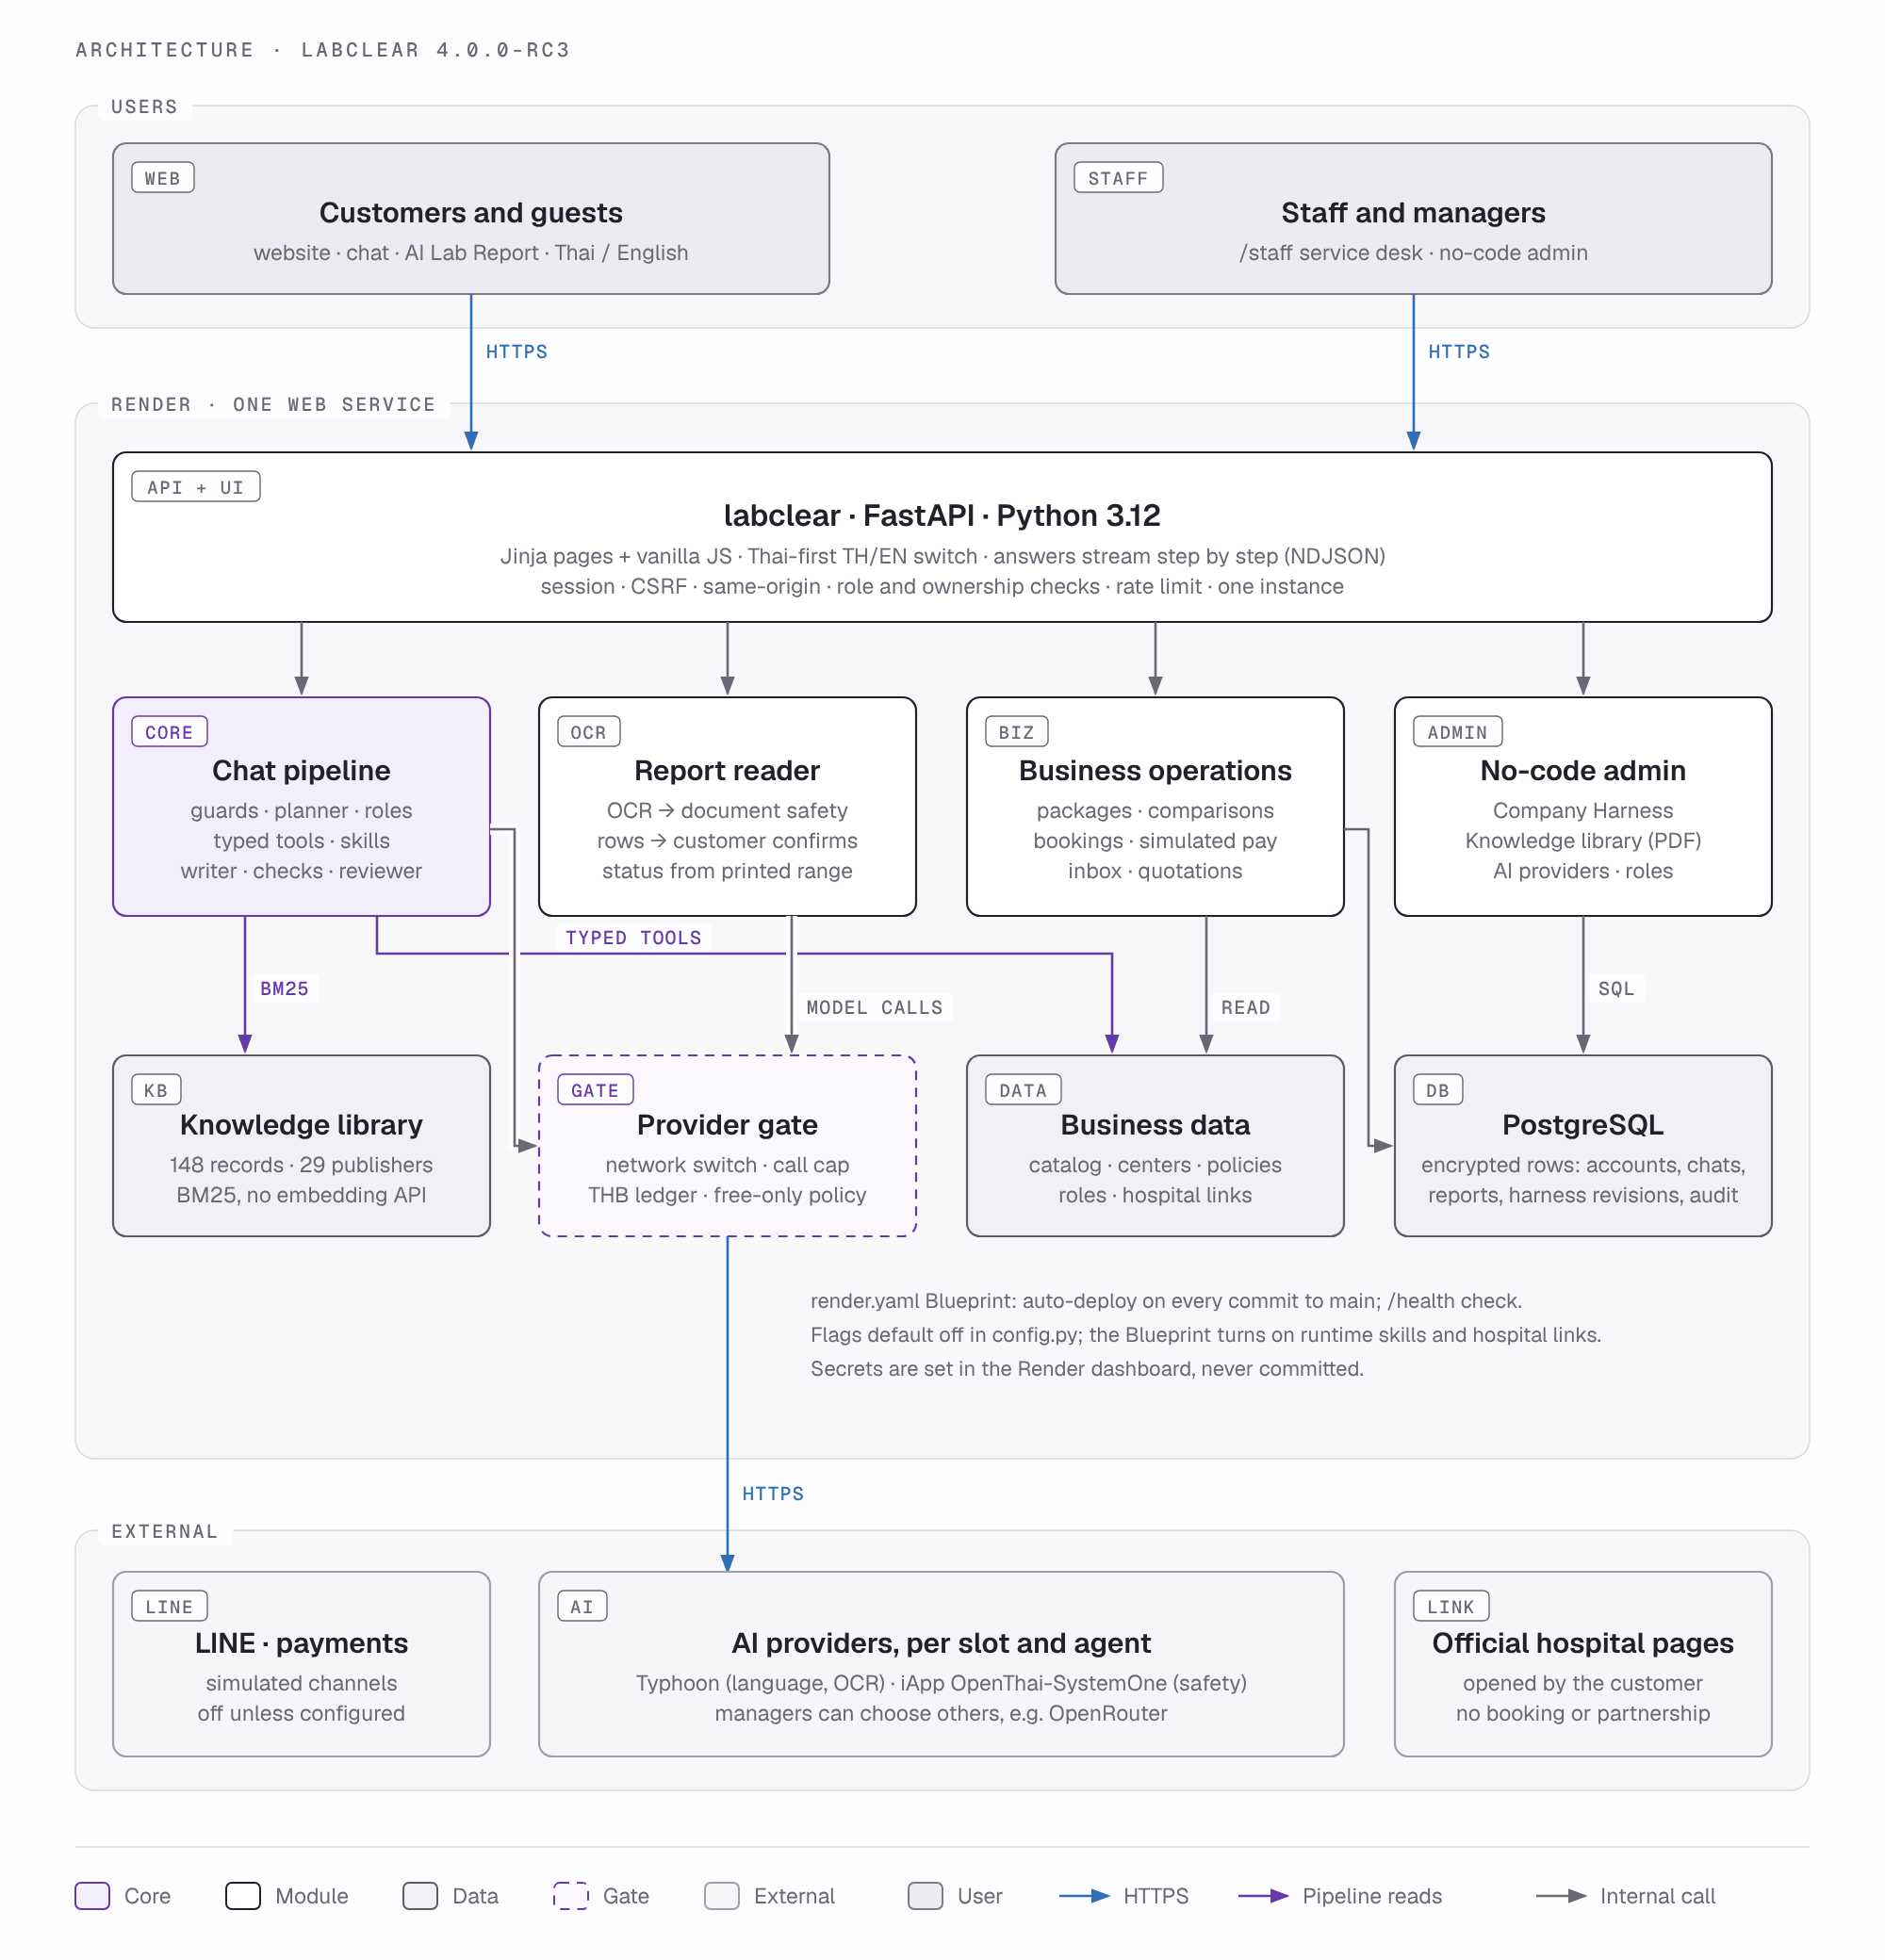

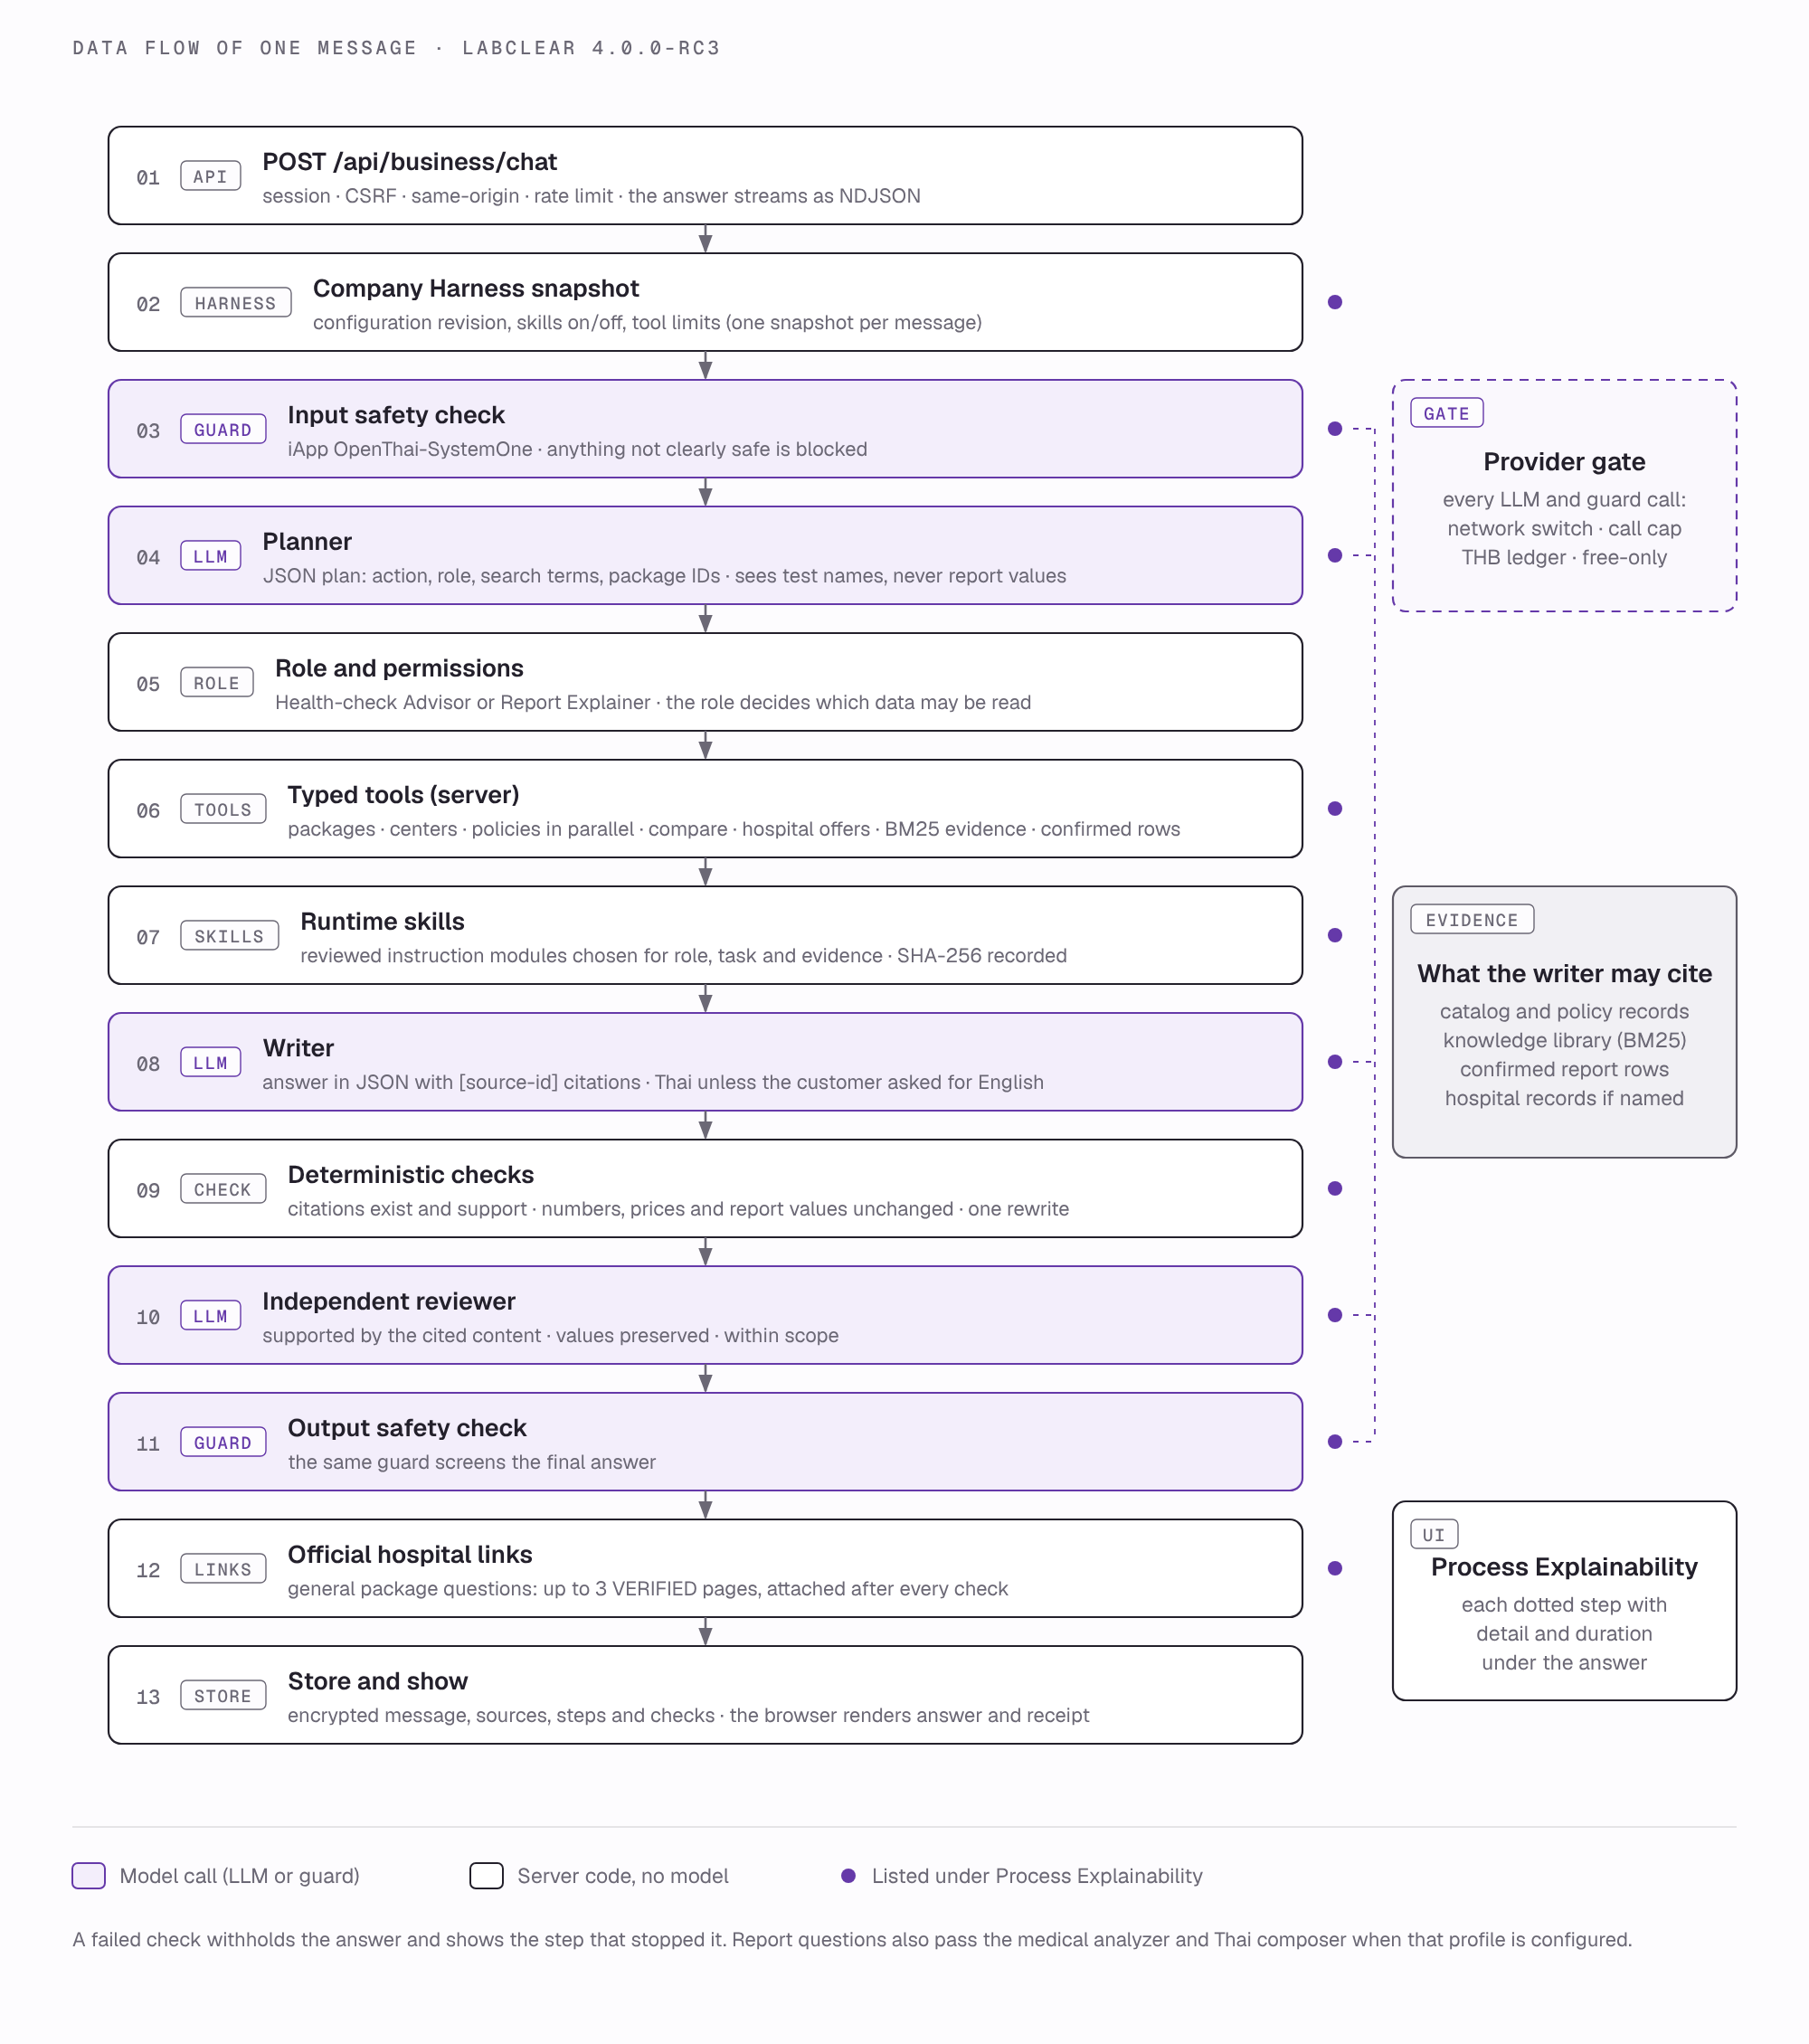

In [2]:
display(Image(filename=str(ROOT/"docs/assets/architecture.png"), width=900))
display(Image(filename=str(ROOT/"docs/assets/message-flow.png"), width=900))

The agents are model slots with narrow jobs. The two customer-facing **roles** (Health-check Advisor and Report Explainer) differ in the data the server lets them read; the role decides the typed tools, not the model.

In [3]:
from services import providers
roles = json.loads((ROOT/"business_data/dots.json").read_text())["dots"]
rows = [("Safety guard", "guard", "Screens every message, answer and report; anything not clearly safe is blocked.")]
rows += [(label, providers.agent_slot(a), help_text) for a, (label, help_text) in providers.AGENTS.items()]
md = "| Agent | Slot | Job |\n|---|---|---|\n" + "\n".join(f"| {a} | `{s}` | {j} |" for a, s, j in rows)
md += "\n\n| Role | Reads (server-enforced) | Actions |\n|---|---|---|\n" + "\n".join(
    f"| {r['name']} | {', '.join(r['reads'])} | {', '.join(r['actions'])} |" for r in roles if r.get("enabled", True))
display(Markdown(md))

| Agent | Slot | Job |
|---|---|---|
| Safety guard | `guard` | Screens every message, answer and report; anything not clearly safe is blocked. |
| Planner | `agent_plan` | Reads each message and chooses the action, the search and the assistant role. |
| Health-check Advisor | `agent_advisor` | Writes answers about packages, booking and payment. |
| Report Explainer | `agent_explainer` | Writes explanations of the values in a confirmed lab report. |
| Reviewer | `agent_review` | Checks every draft against its sources before it is shown. A different model family makes this check more independent. |
| Medical analyzer | `agent_medical_analyzer` | Opt-in typed analysis of confirmed values; no default provider or key. |
| Thai composer | `agent_thai_composer` | Opt-in communication of validated analysis; existing review and guards still apply. |

| Role | Reads (server-enforced) | Actions |
|---|---|---|
| Health-check Advisor | catalog, branches, policies, medical, customer_bookings | answer, clarify, redirect, urgent, quote, book, pay, organization, handoff, link |
| Report Explainer | report, medical, policies | answer, clarify, redirect, urgent, handoff |

## 2. Company Harness
Managers tune the harness on `/staff → Company Harness` without code. Each save is a new revision; the core, citation and scope modules stay on, and a tool's limits can only be lowered. One snapshot is taken per message and recorded with the answer.

In [4]:
from config import settings
from services import agent_tools, harness_config, runtime_skills
settings.RUNTIME_SKILLS_ENABLED = True  # as in render.yaml
config = harness_config.defaults()
print("Default revision:", config["revision"], "· sha256", harness_config.digest(config)[:16], "· locked:", ", ".join(sorted(harness_config.LOCKED)))
manifest = runtime_skills._manifest()
md = "| Runtime skill | Version | Boundary |\n|---|---|---|\n" + "\n".join(
    f"| `{m['id']}` | {m['version']} | {m['boundary']} |" for m in manifest["module_meta"].values())
md += "\n\n| Typed tool | Scope | Timeout s | Max items |\n|---|---|---:|---:|\n" + "\n".join(
    f"| `{t['name']}` | {t['scope']} | {t['timeout_seconds']} | {t['max_items']} |" for t in agent_tools.describe())
display(Markdown(md))

Default revision: 0 · sha256 0181265c0acfaa58 · locked: core.md, evidence-citation.md, scope-uncertainty.md


| Runtime skill | Version | Boundary |
|---|---|---|
| `core` | 0.2.0 | Input: role, evidence, confirmed observations. Output: grounded answer in the caller's JSON shape. Never: secrets, invented sources, diagnoses, doses. |
| `thai-style` | 0.2.0 | Input: any answer draft. Output: plain Thai (or the language the user asked for) with numbers, units, negation and uncertainty unchanged. |
| `evidence-citation` | 0.3.0 | Input: EVIDENCE records. Output: [id] citations that the cited record's own content supports; exact numbers and units. |
| `scope-uncertainty` | 0.3.0 | Input: medical evidence, a report or an urgent/clarify action. Output: in-scope answer with evidence-strength wording and the host's next step. |
| `lay-explanation` | 0.3.0 | Input: medical evidence without a confirmed report. Output: general explanation of a test; no personal conclusion from typed values. |
| `patient-explanation` | 0.2.0 | Input: confirmed report rows and evidence. Output: explanation tied to the printed ranges; roles that read reports only. |
| `package-advice` | 0.2.0 | Input: catalog records. Output: package information and tradeoffs; roles that may quote only; never clinical indications. |
| `package-compare` | 0.3.0 | Input: the deterministic rs-compare table. Output: the practical difference without recomputing; roles that may quote only. |

| Typed tool | Scope | Timeout s | Max items |
|---|---|---:|---:|
| `lookup_packages` | catalog | 2 | 40 |
| `compare_packages` | catalog | 2 | 1 |
| `lookup_branches` | branches | 2 | 1 |
| `lookup_policies` | policies | 2 | 1 |
| `retrieve_evidence` | medical | 10 | 8 |
| `get_confirmed_report_rows` | report | 2 | 1 |
| `preview_booking` | catalog | 2 | 1 |
| `get_external_hospital_offer` | catalog | 2 | 20 |

## 3. Rollout through the real HTTP API
`scripts/demo_harness.py` starts the application in an isolated process (no outbound sockets, temporary storage), then sends five synthetic turns as a browser would:

| Turn | Message |
|---|---|
| question | HbA1c question in Thai (Advisor, knowledge search) |
| hospital | a question naming a real hospital (official offers become cited evidence) |
| packages | a general package question (official hospital links attached after every check) |
| read | upload of the synthetic renal report PNG (OCR → document safety → rows) |
| explain | the customer confirms the rows; the Report Explainer explains them |

No gold rows are sent to the application. The prompt log keeps only synthetic content; image bytes are replaced by the fixture hash.

In [5]:
result = subprocess.run([PY, "scripts/demo_harness.py"], cwd=ROOT, text=True, capture_output=True, timeout=600)
assert result.returncode == 0, result.stderr[-2000:]
print(result.stdout)
rollout = json.loads((ROOT/"docs/evidence/current/demo-rollout.json").read_text())
print("Fixture SHA-256:", rollout["fixture_sha256"])
print(rollout["note"])

Recorded 15 observable provider calls to /home/claude/labclear/docs/evidence/current/demo-rollout.json

Fixture SHA-256: 4d24c82a4c0d6700e9e04df86350c9f839f21ecba403c3b9a0dcbcea2e4e735e
Confirmation is simulated as read. OCR mistakes remain visible. Prompts and outputs are observable artifacts, not private model reasoning.


## 4. Steps, tools and skills per turn
These are the events the browser receives while the answer is prepared; the finished list is stored with the answer and shown under **Process Explainability**. Durations describe this local offline run only.

In [6]:
for name, turn in rollout["turns"].items():
    if not turn: continue
    res = turn.get("result") or {}
    print(f"\n=== TURN: {name} · HTTP {turn.get('status')} · {turn.get('total_ms', 0):.0f} ms" + (f" · ERROR {turn['error']}" if turn.get("error") else ""))
    for e in turn.get("events", []):
        if e.get("type") == "step" and e.get("state") in ("done", "error"):
            print(f"  {e.get('id', ''):<34} {e.get('label', '')[:58]:<58} {e.get('duration_ms', '')}")
    checks = res.get("checks") or {}
    if checks:
        print("  harness:", checks.get("harness"))
        print("  skills :", (checks.get("skills") or {}).get("modules"))
        print("  tools  :", [f"{t['tool']}({'ok' if t.get('ok') else t.get('code')})" for t in checks.get("tools", [])])
    if res.get("sources"):
        print("  cited  :", [s.get("id") for s in res["sources"]][:12])


=== TURN: question · HTTP 200 · 169 ms
  harness                            Company Harness                                            0.0
  safety_in                          Your message passed the safety check                       12.1
  plan                               Plan: answer the question, as the Health-check Advisor     83.8
  tool_lookup_packages               Tool: lookup_packages                                      0.5
  tool_lookup_branches               Tool: lookup_branches                                      0.1
  tool_lookup_policies               Tool: lookup_policies                                      0.1
  data                               Loaded business data the Health-check Advisor may use      0.0
  tool_retrieve_evidence             Tool: retrieve_evidence                                    15.3
  search                             Found 6 medical sources for "HbA1c"                        15.4
  skills                             Runtime skills load

## 5. Full prompts and outputs
Expand any call to see the exact synthetic input it received and the artifact it returned. Calls are listed in order across all turns: guard, planner, writer, reviewer, OCR, row extraction, analyzer.

In [7]:
for i, call in enumerate(rollout["prompts"], 1):
    content = json.dumps(call, ensure_ascii=False, indent=2)
    display(HTML("<details><summary><b>" + str(i) + " · " + html.escape(call["stage"]) + " · " + html.escape(call["model"]) + "</b></summary><pre style='white-space:pre-wrap;max-height:600px;overflow:auto'>" + html.escape(content) + "</pre></details>"))

## 6. Official hospital links
A question that names a hospital receives the reviewed offers as cited evidence (`official_external`, never a booking or partnership). A general package question gets up to three offers whose price is current (VERIFIED), attached by Python after every check; the model never sees them.

In [8]:
hospital = rollout["turns"]["hospital"]["result"]
print("Named hospital · cited records:", [s["id"] for s in hospital["sources"] if s["id"].startswith("hosp-")])
packages = rollout["turns"]["packages"]["result"]
for o in packages["external_offers"]:
    print(f"General question · link: {o['hospital']} · {o['variant']} · {o['price_thb']:,} THB · checked {o['checked_at']} · {o['url']}")

Named hospital · cited records: ['hosp-002', 'hosp-001', 'hosp-001b', 'hosp-003', 'hosp-004', 'hosp-005', 'hosp-006']
General question · link: โรงพยาบาลสมิติเวช · Diabetes & Health Check-up Program · 7,500 THB · checked 2026-10-09 · https://www.samitivejhospitals.com/package/detail/advance-diabetic-check-up-program
General question · link: โรงพยาบาลกรุงเทพ · Essence Check-up · อายุน้อยกว่า 30 ปี · 5,500 THB · checked 2026-10-09 · https://www.bangkokhospital.com/th/bangkok/package/health-check-up-packages
General question · link: โรงพยาบาลกรุงเทพ · Superior Check-up · อายุ 30–40 ปี · 13,500 THB · checked 2026-10-09 · https://www.bangkokhospital.com/th/bangkok/package/health-check-up-packages


## 7. Deterministic benchmark scores
`scripts/score_benchmark.py` re-scores a recorded run with no network, model judge, clock or randomness; the same raw outputs always give byte-identical scores. Every planned case stays in the denominator. All runs below are OFFLINE: equal pass counts across profiles do not show that one profile is better.

In [9]:
rows = []
for score_file in sorted((ROOT/"docs/evidence/current").glob("*/score.json")):
    s = json.loads(score_file.read_text())
    o = s["ocr"]
    rows.append(f"| {score_file.parent.name} | {s['mode']} | {s['profile']} | {s['automated_pass']}/{s['planned']} | {o['values_exact']}/{o['expected_rows']} | `{s['score_sha256'][:12]}` |")
display(Markdown("| Run | Mode | Profile | Automated pass | Exact OCR values | Score hash |\n|---|---|---|---:|---:|---|\n" + "\n".join(rows)))
run = sorted(p for p in (ROOT/"docs/evidence/current").glob("*ocr*") if (p/"raw.jsonl").exists())[-1]
one = subprocess.check_output([PY, "scripts/score_benchmark.py", str(run)], cwd=ROOT)
two = subprocess.check_output([PY, "scripts/score_benchmark.py", str(run)], cwd=ROOT)
assert one == two
print("Re-scored", run.name, "twice: byte-identical; score", json.loads(one)["score_sha256"][:16])

Re-scored rc3-ocr-C twice: byte-identical; score 795ad3fb33f9ac4c


| Run | Mode | Profile | Automated pass | Exact OCR values | Score hash |
|---|---|---|---:|---:|---|
| owner-coursework-A | OFFLINE | A | 15/20 | 88/93 | `0005e76f9d86` |
| owner-coursework-B2 | OFFLINE | B | 15/20 | 88/93 | `0005e76f9d86` |
| owner-coursework-C | OFFLINE | C | 15/20 | 88/93 | `0005e76f9d86` |
| owner-ocr-C | OFFLINE | C | 0/12 | 217/252 | `795ad3fb33f9` |
| rc3-coursework-A | OFFLINE | A | 15/20 | 88/93 | `0005e76f9d86` |
| rc3-coursework-B | OFFLINE | B | 15/20 | 88/93 | `0005e76f9d86` |
| rc3-coursework-C | OFFLINE | C | 15/20 | 88/93 | `0005e76f9d86` |
| rc3-ocr-C | OFFLINE | C | 0/12 | 217/252 | `795ad3fb33f9` |

The uploaded images and PDFs are verified against the frozen manifest before any run:

O01-PNG 01_A_Liver.png 414394 bytes
O01-PDF 01_A_Liver.pdf 37638 bytes
O02-PNG 02_A_Renal.png 418971 bytes
O02-PDF 02_A_Renal.pdf 39090 bytes
O03-PNG 03_B_Lipid.png 442895 bytes
O03-PDF 03_B_Lipid.pdf 33834 bytes
O04-PNG 04_B_Glucose_Urine.png 426813 bytes
O04-PDF 04_B_Glucose_Urine.pdf 34104 bytes
O05-PNG 05_C_Hematology.png 604163 bytes
O05-PDF 05_C_Hematology.pdf 42697 bytes
O06-PNG 06_C_Thyroid.png 601661 bytes
O06-PDF 06_C_Thyroid.pdf 42802 bytes


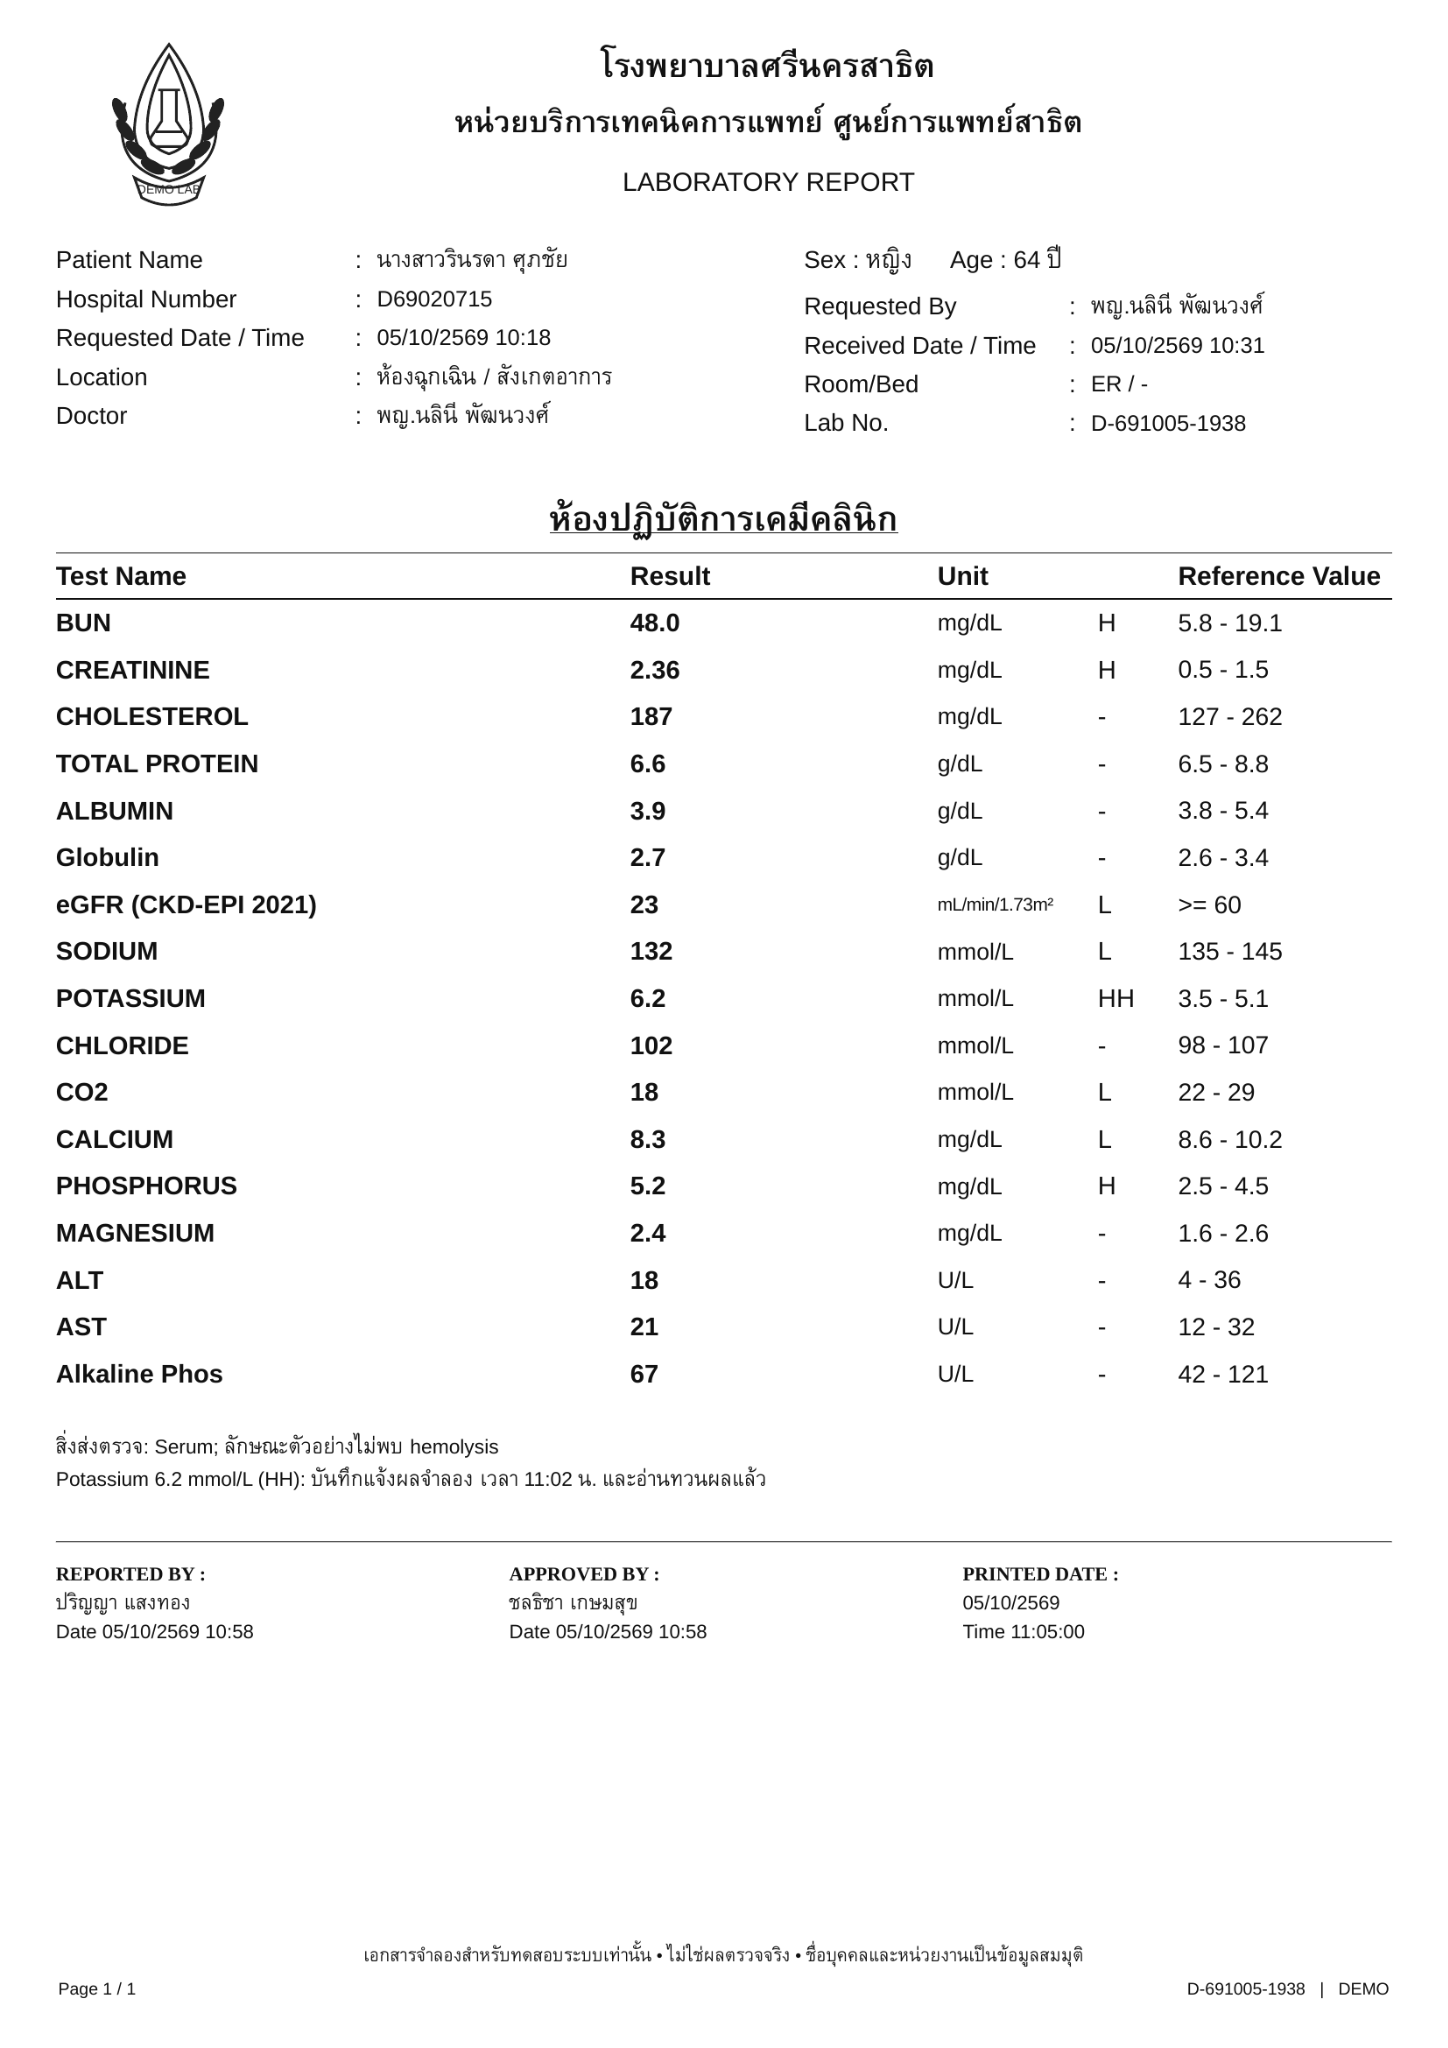

In [10]:
dataset = json.loads((ROOT/"eval/ocr_files/dataset.json").read_text())
for case in dataset["cases"]:
    path = ROOT/case["image"]
    assert hashlib.sha256(path.read_bytes()).hexdigest() == case["image_sha256"]
    print(case["id"], path.name, path.stat().st_size, "bytes")
display(Image(filename=str(ROOT/"examples/ocr_owner_20261009/png/02_A_Renal.png"), width=500))

## 8. Resilience: success, provider timeout and cancellation
Every AI request runs inside one execution context (`services/execution.py`): a request ID, a workflow deadline (220 s for chat), an admission slot and a cancellation scope. The stream sends `accepted`, steps, a `heartbeat` after 10 s without output, and exactly one terminal event. The three rollouts below use the real application with provider doubles on a **virtual clock**, so the 60-second provider timeout takes milliseconds to run; the times shown are virtual seconds, not latency. Only the events the browser receives and the structured log line are recorded: no prompts, no model reasoning.

The deterministic fault suite R01–R12 is `scripts/benchmark_resilience.py --offline` (results in `docs/evidence/current/resilience/`).

In [11]:
import tempfile
out = ROOT/"docs/evidence/current/resilience/demo-rollouts.json"
with tempfile.TemporaryDirectory() as tmp:
    cfg = Path(tmp)/"demo.json"
    cfg.write_text(json.dumps({"workdir": str(Path(tmp)/"work"), "out": str(out), "demo": True}))
    run = subprocess.run([PY, "scripts/offline_check.py", "resilience", str(cfg)], cwd=ROOT, text=True, capture_output=True, timeout=300)
assert run.returncode == 0, run.stderr[-2000:]
demo = json.loads(out.read_text())
for r in demo["rollouts"]:
    log = r["workflow_log"]
    print(f"\n=== {r['name']} · {r['request_id']} · outcome {log.get('outcome')} · code {log.get('code')} · origin {log.get('origin')} · step {log.get('step')} · provider calls {log.get('attempts')}")
    beats = sum(e["type"] == "heartbeat" for e in r["events"])
    for e in r["events"]:
        if e["type"] == "heartbeat":
            continue
        if e["type"] == "step" and e["id"].startswith("tool_") and e["state"] == "running":
            continue
        what = e.get("label") or e.get("code") or ""
        extra = f" · {e['duration_ms']/1000:.1f} s" if e.get("duration_ms") and e["state"] not in ("done",) else ""
        print(f"  {e['t']:8.3f} s  {e['type']:9} {e.get('id', ''):24} {e.get('state', ''):10} {what}{extra}")
    print(f"  heartbeats: {beats} · cancelled provider calls: {r['provider_calls_cancelled'] or 'none'}")


=== success · req_99fd64dd45e08bda · outcome done · code None · origin None · step safety_out · provider calls 5
     0.001 s  accepted                                      
     0.003 s  step      harness                  done       Company Harness
     0.003 s  step      safety_in                running    Checking your message for safety
     0.011 s  step      safety_in                done       Your message passed the safety check
     0.014 s  step      plan                     running    Understanding your request
     0.137 s  step      plan                     done       Plan: answer the question, as the Health-check Advisor
     0.137 s  step      tool_lookup_packages     done       Tool: lookup_packages
     0.137 s  step      tool_lookup_branches     done       Tool: lookup_branches
     0.137 s  step      tool_lookup_policies     done       Tool: lookup_policies
     0.137 s  step      data                     done       Loaded business data the Health-check Advisor may u

The recorded fault-suite result (12 required cases, equal weight; a case passes only when all its assertions pass):

In [12]:
bench = json.loads((ROOT/"docs/evidence/current/resilience/resilience-benchmark.json").read_text())
print(f"score {bench['score']} · {bench['passed']}/{bench['required']} passed · skipped {bench['skipped']} · outbound connection attempts {bench['outbound_connection_attempts']} · commit {bench['commit'][:7]}")
display(Markdown("| Case | Scenario | Assertions | Result |\n|---|---|---|---|\n" + "\n".join(
    f"| {c['id']} | {c['title']} | {c['assertions_passed']}/{c['assertions']} | {'PASS' if c['passed'] else 'FAIL'} |" for c in bench["cases"])))

score 100.0 · 12/12 passed · skipped 0 · outbound connection attempts 0 · commit ebdaa6f


| Case | Scenario | Assertions | Result |
|---|---|---|---|
| R01 | Provider hangs or sends data slowly without end | 23/23 | PASS |
| R02 | Provider 502/503/429 and malformed output | 37/37 | PASS |
| R03 | A proxy answers with an HTML 502/503/504 page | 14/14 | PASS |
| R04 | Idle stream, a stream cut before done, an invalid line | 14/14 | PASS |
| R05 | Stop or a closed connection while waiting for AI | 13/13 | PASS |
| R06 | More users than the concurrency limit | 14/14 | PASS |
| R07 | Broken PDF, too many pages, too many pixels, a stuck worker | 13/13 | PASS |
| R08 | Slow storage: connection, query or lock | 13/13 | PASS |
| R09 | SIGTERM during a chat and a report read | 10/10 | PASS |
| R10 | Retry clicked twice, or while the original request is active | 11/11 | PASS |
| R11 | Cold start and pages that are not JSON | 11/11 | PASS |
| R12 | Request IDs, logs without secrets, existing regressions | 10/10 | PASS |

## 9. Running with live Thai APIs
Use `scripts/benchmark_labclear.py preflight` with an account-specific, verified free-tier policy, then run `--mode live-free` on synthetic data only. Keys belong in the trial environment, never in this notebook. Start with the smoke suite, respect the shared ledger and quota, and keep every attempt. A connectivity test checks one response format; a live benchmark measures the configured pipeline; Thai readability, source entailment and clinical scope still need human review. No live run has been recorded for this release because no provider keys were available.